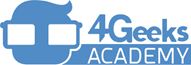

<h1><b>Data Science and Machine Learning</b></h1>
<h2><b>Clase 17</b>: Regresión lineal</h2>
<h3><b>Docente</b>: <a href="https://www.linkedin.com/in/danielablanco/">Daniela Blanco</a>

# Contenido

- [1. ¿Para qué sirve?](#paraque)
  - [1.1. Regresión lineal simple](#simple)
  - [1.2. Regresión lineal multiple](#multiple)
  - [1.3. Método de ajuste](#metodo)
- [2. Supuestos de la Regresión lineal](#supuestos)
- [3. Métricas](#metricas)
- [4. Ejemplo práctico](#ejemplo)
- [5. Regularización](#regularizacion)
  - [5.1. Lasso o L1](#lasso)
  - [5.2. Ridge o L2](#ridge)
- [5. Ejemplo regularización](#ejemplo_reg)
- [7. Links de interés](#links)


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge

from sklearn.metrics import mean_squared_error, r2_score

## 1. ¿Para qué sirve? <a name="paraque"></a>

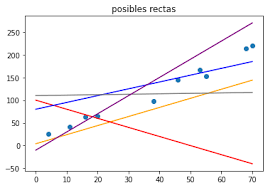

La regresión lineal (linear regression) es un tipo de modelo que se utiliza para predecir el valor de una variable dependiente (o variable objetivo) basado en el valor de una o más variables independientes (o variables predictoras).

Es decir para problemas **supervisados** de **regresión** ya que predice un valor continuo.

Si la relación entre la variable objetivo es con una única variable predictora, se dice que la **regresión** es **simple**. Si es con varias predictoras, recibe el nombre de **regresión múltiple**.

### 1.2. Regresión lineal simple <a name="simple"></a>

Involucra una sola variable independiente.

La regresión lineal simple permite estudiar las relaciones entre dos variables numéricas continuas.

En este tipo de regresión intentamos ajustar una línea recta a los datos que mejor describa la relación entre las dos variables.

Es decir, buscamos una línea que minimice la distancia vertical entre sí misma y todos los puntos de datos, de tal forma que la mejor relación lineal se da cuando todos los puntos conforman la recta y no existe dispersión.

La ecuación que define esta relación (recta) es:

$$ y = \beta_0 + \beta_1 x + \epsilon $$

- $y$: Variable dependiente (lo que se predice).
- $x$: Variable independiente (la que se usa para predecir).
- $\beta_0$: Intercepto (valor de $y$ cuando $x$ es 0).
- $\beta_1$: Pendiente (cambio en $y$ por un cambio unitario en $x$.
- $\epsilon$: Término de error (residuo). Diferencia entre valor real de $y$ y el predicho.

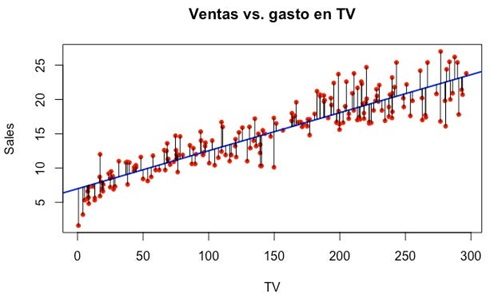

Intercepto y pendiente son los coeficientes que el modelo aprenderá.

El objetivo de la regresión lineal simple es, por lo tanto, encontrar los mejores valores de $\beta_0$ y $\beta_1$ que minimizan el error $\epsilon$.

Una vez que hemos encontrado estos valores, podemos usarlos para predecir los valores de $y$ dada cualquier $x$.

### 1.2. Regresión lineal multiple <a name="multiple"></a>

Involucra dos o más variables independientes.

Se usa para modelar la relación entre dos o más características y una variable respuesta mediante el ajuste de una ecuación lineal a los datos observados.

La forma básica de una ecuación de regresión lineal múltiple con **n** variables es:

$$
y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \ldots + \beta_n x_n + \epsilon
$$

- $y$: Variable dependiente (que intentamos predecir).
- $x_1$, $x_2$, $\ldots$, $x_n$ \: Variables independientes (las usamos para predecir).
- $\beta_0$: Intercepto.
- $\beta_1$, $\beta_2$, $\ldots$, $\beta_n$: Coeficientes de las variables independientes.
- $\epsilon$: Término de error (residuo).

$\beta_0$, $\beta_1$, $\beta_2$, $\ldots$, $\beta_n$ son los coeficientes que el modelo aprenderá.

El objetivo de la regresión lineal multiple es, por lo tanto, encontrar los mejores valores de $\beta$ que minimizan el error $\epsilon$.

Permite determinar qué variables en particular tienen un impacto significativo sobre la variable dependiente y en qué magnitud.


### 1.3. Método de ajuste <a name="metodo"></a>


La técnica más común para ajustar un modelo de regresión lineal es el Método de los Mínimos Cuadrados Ordinarios (OLS, por sus siglas en inglés), que minimiza la suma de los cuadrados de los residuos (errores).

$$ \text{Residual Sum of Squares (RSS)} = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 $$

Donde:
- $n$: Número de observaciones.
- $y_i$: Valor observado para la $i$-ésima observación.
- $\hat{y}_i$: Valor predicho para la $i$-ésima observación por el modelo.

## 2. Supuestos de la Regresión lineal <a name="supuestos"></a>

Este modelo se fundamenta en torno a cinco supuestos, que son los siguientes:

- Linealidad: La variable objetivo y la(s) predictora(s) tienen una **relación lineal**.

- Independencia: Las observaciones son independientes unas de otras.

- Homoscedasticidad: La varianza de los errores (es decir, las diferencias entre las predicciones del modelo y los datos reales) es constante en todas las observaciones.

- Normalidad de los errores: Los errores están normalmente distribuidos.

- Ausencia de multicolinealidad: En una regresión múltiple, las variables independientes no están perfectamente correlacionadas entre sí. Si hay correlación perfecta, se dice que los datos tienen multicolinealidad (hay variables que son iguales) y dificulta el cálculo de los coeficientes.

**¿Cómo evaluamos los supuestos?**

- Linealidad:

Método: Inspeccionar gráficos de dispersión (scatter plots) entre las variables independientes y la variable dependiente.

La relación debería mostrarse aproximadamente como una línea recta.

Solución si no se cumple: Transformaciones de las variables (logarítmica, cuadrática, etc.) o usar modelos no lineales.

- Independencia:

Revisar la metodología de muestreo y utilizar el test de Durbin-Watson para detectar autocorrelación en los residuos.

Valores del test de Durbin-Watson cercanos a 2 sugieren que no hay autocorrelación.

Solución si no se cumple: incluir variables adicionales.

- Homoscedasticidad

Analizar un gráfico de residuos vs. valores predichos.

Los residuos deberían distribuirse aleatoriamente alrededor del cero sin mostrar patrones claros.

Solución si no se cumple: usar modelos de regresión robusta.

- Normalidad de los Errores:

Utilizar histogramas y gráficos Q-Q (cuantiles-cuantiles) de los residuos.

Los residuos deberían seguir una distribución normal.

Solución si no se cumple: utilizar métodos no paramétricos.

- No Multicolinealidad:

Calcular el Factor de Inflación de la Varianza (VIF) para cada variable independiente.

VIF < 10 generalmente sugiere que no hay un problema serio de multicolinealidad.

Solución si no se cumple: Eliminar o combinar variables altamente correlacionadas, o utilizar técnicas de regularización como la regresión Ridge o Lasso.

## 4. Métricas <a name="metricas"></a>

La **evaluación** de un modelo es uno de los pasos más importantes en el proceso de Machine Learning, ya que nos va a permitir saber cómo de bueno es nuestro modelo, cuánto ha aprendido de la muestra de entrenamiento (`train`) y cómo procederá para datos nunca vistos o nuevos (`test` y/o `validación`).

Para evaluar un modelo existen métricas según el tipo de problema y aprendizaje.

El paquete `scikit-learn` permite fácilmente aplicar estas funciones a los modelos. La documentación está accesible [aquí](https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics).

### Métricas para modelos de regresión

Un **modelo de regresión** se utiliza para predecir un valor continuo.

- **Error absoluto medio** (*Mean Absolute Error, MAE*).

Media de la diferencia absoluta entre las predicciones y los valores reales.

Es menos sensible a valores extremos que el MSE.

Valores bajos me indica que predice bien. Se equivoca poco en promedio.

   $$
   MAE = \frac{1}{n} \sum_{i=1}^n \left| y_i - \hat{y}_i \right|
   $$

- **Error cuadrático medio** (*Mean Squared Error, MSE*).

Similar al anterior, pero eleva al cuadrado las diferencias antes de realizar la división.

Penaliza más las diferencias grandes que el MAE.

Un MSE más bajo indica que las predicicones están más cerca de los valores reales en promedio. No se puede interpretar en la unidad de la variable objetivo por elevar al cuadrado.

   $$
   MSE = \frac{1}{n} \sum_{i=1}^n \left( y_i - \hat{y}_i \right)^2
   $$

   - **Error cuadrático medio de la raíz** (*Root Mean Squared Error, RMSE*).

Es la raíz cuadrada del MSE.

Similar al MSE pero las unidades son las mismas que las de la variable objetivo. Fácil interpretación.

   $$
   RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^n \left( y_i - \hat{y}_i \right)^2}
   $$

- **Coeficiente de determinación** ($R^2$).

Mide la proporción de la variación en la variable objetivo que es explicada por las carácterísticas del modelo.

Será un valor entre 0 y 1. Donde a más alto valor mejor predice. El modelo explica una mayor proporcion de la variabilidad de los datos.

   $$
   R^2 = 1 - \frac{\sum_{i=1}^n \left( y_i - \hat{y}_i \right)^2}{\sum_{i=1}^n \left( y_i - \bar{y} \right)^2}
   $$

## 4. Ejemplo práctico <a name="ejemplo"></a>

### Regresión lineal simple

Para ejemplificar la implementación de un modelo de regresión lineal simple utilizaremos un conjunto de datos con pocas instancias y que ya ha sido previamente tratado con un EDA completo.

####Paso 1. Lectura del conjunto de datos procesado

In [2]:
# conexion drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
archivo = '/content/drive/MyDrive/4Geeks/DS/2.0/17_regresion_lineal/data/clean_salary_train.csv'
train_data = pd.read_csv(archivo)

train_data.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,2.0,43525.0
3,2.2,39891.0
4,2.9,56642.0


In [4]:
train_data.shape

(24, 2)

In [5]:
archivo = '/content/drive/MyDrive/4Geeks/DS/2.0/17_regresion_lineal/data//clean_salary_test.csv'
test_data = pd.read_csv(archivo)

test_data.head()

,YearsExperience,Salary
0,1.5,37731.0
1,3.0,60150.0
2,4.5,61111.0
3,6.8,91738.0
4,8.2,113812.0


In [6]:
test_data.shape

(6, 2)

Utilizando un diagrama de puntos se visualizará la relación entre la variable predictora y la objetivo (esto se ve en el análisis univariante):

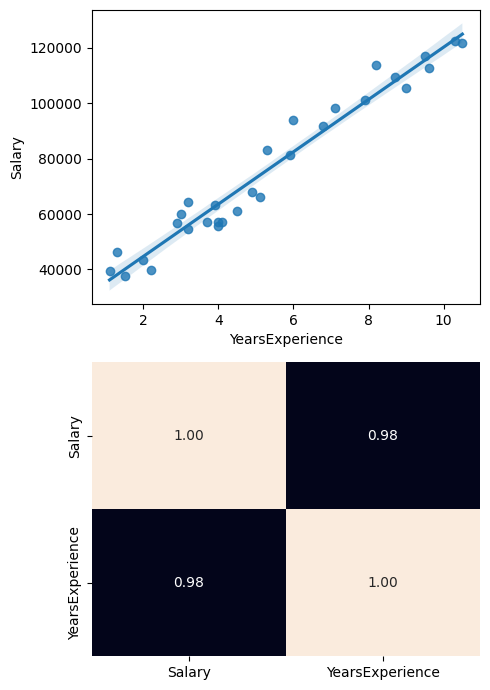

In [7]:
fig, axis = plt.subplots(2, 1, figsize = (5, 7))
total_data = pd.concat([train_data, test_data])

sns.regplot(ax = axis[0], data = total_data, x = "YearsExperience", y = "Salary")

sns.heatmap(total_data[["Salary", "YearsExperience"]].corr(), annot = True, fmt = ".2f", ax = axis[1], cbar = False)

plt.tight_layout()

plt.show()

Existe una clara relación lineal entre la variable predictora y la objetivo, así que puede ser fácilmente modelable por este tipo de modelos.

Si la correlación fuera inferior, el modelo no tendría una buena precisión.

El conjunto *train* lo utilizaremos para entrenar el modelo, mientras que el conjunto *test* lo evaluaremos para medir su grado de efectividad. Dividiremos también las predictoras de las características.

Además, al haber únicamente una variable predictora, no es necesario aplicar una normalización. En el caso de que hubiera varias, sí que habría que aplicarla.

In [8]:
X_train = train_data.drop(["Salary"], axis = 1)
y_train = train_data["Salary"]

X_test = test_data.drop(["Salary"], axis = 1)
y_test = test_data["Salary"]

#### Paso 2: Inicialización y entrenamiento del modelo

In [9]:
# instanciamos el modelo con valores por defecto
model = LinearRegression()

# entrenamos
model.fit(X_train, y_train)

LinearRegression()

Después del proceso de entrenamiento podemos conocer los parámetros (variables $a$ y $b$) que ha ajustado el modelo:

In [11]:
print(f"Intercepto (b0): {model.intercept_}")
print(f"Coeficientes (b1): {model.coef_}")

Intercepto (b0): 26354.43069701219
Coeficientes (b1): [9277.78307971]


In [12]:
Salary =  26354.43069701219 + 9277.78307971 * 4.5

In [13]:
Salary

68104.4545557072

In [ ]:
4.5	61111.0

#### Paso 3: Predicción del modelo

In [10]:
y_pred = model.predict(X_test)
y_pred

array([ 40271.10531658,  54187.77993614,  68104.45455571,  89443.35563904,
       102432.25195063, 121915.59641802])

Para comparar el valor predicho del original, podemos realizar un gráfico comparativo como el siguiente:

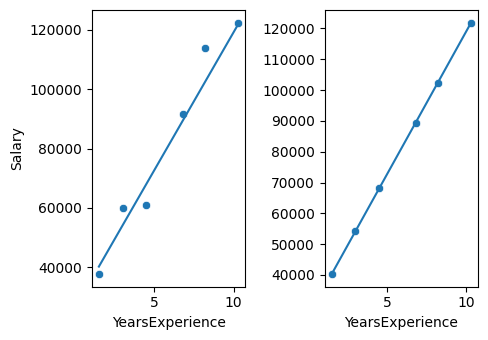

In [14]:
fig, axis = plt.subplots(1, 2, figsize = (5, 3.5))
total_data = pd.concat([train_data, test_data])

# Utilizamos los parámetros ajustados en el entrenamiento para dibujar la línea de regresión en los gráficos
regression_equation = lambda x: 26354.43069701219 + 9277.78307971 * x

sns.scatterplot(ax = axis[0], data = test_data, x = "YearsExperience", y = "Salary")
sns.lineplot(ax = axis[0], x = test_data["YearsExperience"], y = regression_equation(test_data["YearsExperience"]))

sns.scatterplot(ax = axis[1], x = test_data["YearsExperience"], y = y_pred)
sns.lineplot(ax = axis[1], x = test_data["YearsExperience"], y = regression_equation(test_data["YearsExperience"])).set(ylabel = None)

plt.tight_layout()

plt.show()

Como vemos, el test predicho por el modelo siempre se ajustará a la ecuación de regresión, ya que es la que ha aprendido el modelo (derecha).

La figura de la izquierda representa los valores reales, mientras que los de la derecha, los predichos.

Vemos que algunos valores predichos coinciden con los reales, y los que no, tienen una diferencia notable.

#### Paso 4: Evaluación del modelo

Veremos a continuación el valor de la métrica para conocer más acerca del rendimiento del algoritmo.

Para calcular la efectividad del modelo utilizaremos el **error cuadrático medio** (*MSE*) y el **coeficiente de determinación** ($R^2$), unas de las métricas más populares:

In [15]:
print(f"Error cuadrático medio: {mean_squared_error(y_test, y_pred)}")
print(f"Coeficiente de determinación: {r2_score(y_test, y_pred)}")

Error cuadrático medio: 37649779.451336615
Coeficiente de determinación: 0.959714925174946


In [16]:
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(6135.941610815459)

Cuanto menor sea el valor del RMSE, mejor será el modelo.

Un modelo perfecto (un modelo hipotético que siempre pueda predecir el valor esperado exacto) tendría un valor para esta métrica de 0.

Observamos que hay un descuadre de 37 millones, ¿bueno o malo?

Si nos apoyamos en el valor del $R^2$, observamos que es de un 95%, un valor muy alto, luego el 95% de los datos están explicados por el modelo, por lo que es satisfactorio.

#### Paso 5: Optimización de resultados

Este tipo de modelos no se pueden optimizar, debido a la ausencia de hiperparámetros.

### Regresión lineal múltiple

Para ejemplificar la implementación de un modelo de regresión múltiple simple utilizaremos un conjunto de datos que ya ha sido previamente tratado con un EDA completo.

#### Paso 1. Lectura del conjunto de datos procesado

In [17]:
archivo = '/content/drive/MyDrive/4Geeks/DS/2.0/17_regresion_lineal/data/clean_weight-height_train.csv'
train_data = pd.read_csv(archivo)

train_data.head()

,Gender,Height,Weight
0,-1.0,-0.575639,151.275533
1,-1.0,-0.992843,123.965162
2,-1.0,-0.925964,124.765438
3,-1.0,-1.478210,119.195698
4,1.0,-1.598649,146.956646


In [18]:
train_data.shape

(8000, 3)

In [19]:
archivo = '/content/drive/MyDrive/4Geeks/DS/2.0/17_regresion_lineal/data/clean_weight-height_test.csv'
test_data = pd.read_csv(archivo)

test_data.shape

(2000, 3)

Para este problema, queremos calcular el peso (`weight`) en función de la altura (`height`) y del género (`gender`) de la persona.

Por lo tanto, el peso será la variable dependiente (variable objetivo) y la altura y el género, las variables independientes (variables predictoras).

Utilizando un diagrama de puntos se visualizará la relación entre la variable predictora y las variables objetivo (esto se ve en el análisis univariante):

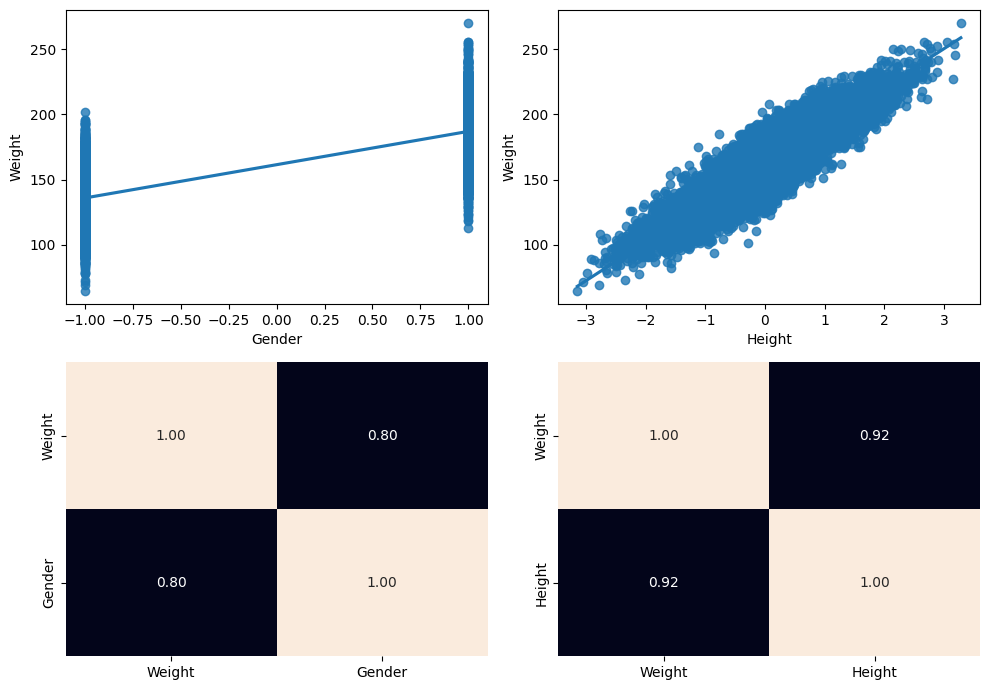

In [20]:
fig, axis = plt.subplots(2, 2, figsize = (10, 7))
total_data = pd.concat([train_data, test_data])

sns.regplot(ax = axis[0, 0], data = total_data, x = "Gender", y = "Weight")
sns.heatmap(total_data[["Weight", "Gender"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 0], cbar = False)

sns.regplot(ax = axis[0, 1], data = total_data, x = "Height", y = "Weight")
sns.heatmap(total_data[["Weight", "Height"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 1], cbar = False)

plt.tight_layout()

plt.show()

Existe una clara relación lineal entre la variable predictora y las objetivo, así que puede ser fácilmente modelable por este tipo de modelos. Si la correlación fuera inferior, el modelo no tendría una buena precisión.

In [21]:
X_train = train_data.drop(["Weight"], axis = 1)
y_train = train_data["Weight"]

X_test = test_data.drop(["Weight"], axis = 1)
y_test = test_data["Weight"]

#### Paso 2: Inicialización y entrenamiento del modelo

In [22]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

Después del proceso de entrenamiento podemos conocer los parámetros (variables $b_0$ y $b_1, b_2$) que ha ajustado el modelo:

In [24]:
X_train

,Gender,Height
0,-1.0,-0.575639
1,-1.0,-0.992843
2,-1.0,-0.925964
3,-1.0,-1.478210
4,1.0,-1.598649
...,...,...
7995,-1.0,-0.480942
7996,1.0,1.931564
7997,-1.0,0.678315
7998,-1.0,0.549421


In [23]:
print(f"Intercepto (b0): {model.intercept_}")
print(f"Coeficientes (b1, b2): {model.coef_}")

Intercepto (b0): 161.48606316160345
Coeficientes (b1, b2): [ 9.65020608 22.88377295]


#### Paso 3: Predicción del modelo

In [25]:
y_pred = model.predict(X_test)
y_pred

array([105.17851056, 188.29501423, 137.05824216, ..., 112.17172027,
       130.89667195, 137.46475059])

#### Paso 4: Evaluación del modelo

In [26]:
print(f"Error cuadrático medio: {mean_squared_error(y_test, y_pred)}")
print(f"Coeficiente de determinación: {r2_score(y_test, y_pred)}")

Error cuadrático medio: 98.21235363443171
Coeficiente de determinación: 0.9075866115171992


Si nos apoyamos en el valor del $R^2$, observamos que es de un 90%, un valor muy alto, luego el 90% de los datos están explicados por el modelo, por lo que es satisfactorio.

#### Paso 5: Optimización de resultados

Este tipo de modelos no se pueden optimizar, debido a la ausencia de hiperparámetros.

## 5. Regularización <a name="regularizacion"></a>

El sobreajuste ocurre cuando un modelo se ajusta demasiado bien a los datos de entrenamiento, capturando ruido y patrones irrelevantes, lo que resulta en un desempeño pobre en datos no vistos.

La regularización en modelos lineales es una técnica utilizada para prevenir el sobreajuste (overfitting) y mejorar la capacidad de generalización del modelo.

Agrega una penalización a la función de costo del modelo para evitar este problema.

Ambas técnicas intentan limitar o "penalizar" el tamaño de los coeficientes del modelo.

**Ventajas de la Regularización**

- Prevención del Sobreajuste: reduce la varianza del modelo y lo hace más robusto frente a nuevos datos.

- Mejora de la Interpretabilidad: Especialmente con L1, se pueden obtener modelos más simples y fáciles de interpretar, ya que puede reducir el número de características.

- Reducción de la Complejidad del Modelo: La penalización ayuda a controlar la magnitud de los coeficientes dejando algunos sin utilizar.

### 5.1. Lasso o L1 <a name="lasso"></a>

Añade una penalización igual al valor absoluto de la magnitud de los coeficientes.

Puede resultar en coeficientes iguales a cero, lo que indica que la característica correspondiente no se utiliza en el modelo.

Lo que resulta en modelos más sencillos y con menos características, también conocido como técnica de selección de características.

$$
\underset{\beta}{\text{Minimizar}} \quad \text{RSS} + \lambda \sum_{j=1}^{p} |\beta_j|
$$

Donde:
- $\text{RSS}$ es la suma de los errores cuadrados residuales.
- $\lambda$ es el parámetro de regularización.
- $|\beta_j|$ es el valor absoluto de los coeficientes.

### 5.2. Ridge o L2 <a name="ridge"></a>

Añade una penalización igual al cuadrado de la magnitud de los coeficientes.

Esto tiende a reducir los coeficientes, pero no los hace exactamente cero, por lo que todas las características se mantienen en el modelo.

Esto puede ser útil para mantener todas las características en el modelo, pero con una influencia reducida.

$$
\underset{\beta}{\text{Minimizar}} \quad \text{RSS} + \lambda \sum_{j=1}^{p} \beta_j^2
$$

Donde:
- $\text{RSS}$ es la suma de los errores cuadrados residuales: $\sum_{i=1}^n (y_i - \hat{y}_i)^2$
- $\lambda$ es el parámetro de regularización (controla la penalización).
- $\beta_j$ son los coeficientes del modelo.


## 6. Ejemplo regularización <a name="ejemplo_reg"></a>

Podemos construir un modelo lineal regularizado fácilmente en Python utilizando la librería `scikit-learn` y las funciones `Lasso` y `Ridge`.

Hiperparámetros más importantes:

- `alpha`: Este es el hiperparámetro de regularización. Controla cuánto queremos penalizar los coeficientes altos.

Un valor más alto aumenta la regularización y, por lo tanto, los coeficientes del modelo tienden a ser más pequeños.

Por el contrario, un valor más bajo la reduce y permite coeficientes más altos.

El valor por defecto es 1.0 y su rango de valores va desde 0.0 hasta infinito.

- `max_iter`: Es el número máximo de iteraciones del modelo.

Para ejemplificar la implementación de un modelo de regresión múltiple simple utilizaremos un conjunto de datos que ya ha sido previamente tratado con un EDA completo.

1. Lectura del conjunto de datos procesado

In [28]:
archivo = '/content/drive/MyDrive/4Geeks/DS/2.0/17_regresion_lineal/data/clean_weight-height_train.csv'
train_data = pd.read_csv(archivo)

train_data.head()

,Gender,Height,Weight
0,-1.0,-0.575639,151.275533
1,-1.0,-0.992843,123.965162
2,-1.0,-0.925964,124.765438
3,-1.0,-1.478210,119.195698
4,1.0,-1.598649,146.956646


In [ ]:
train_data.shape

In [29]:
archivo = '/content/drive/MyDrive/4Geeks/DS/2.0/17_regresion_lineal/data/clean_weight-height_test.csv'
test_data = pd.read_csv(archivo)

test_data.shape

(2000, 3)

Para este problema, queremos calcular el peso (`weight`) en función de la altura (`height`) y del género (`gender`) de la persona.

Por lo tanto, el peso será la variable dependiente (variable objetivo) y la altura y el género, las variables independientes (variables predictoras).

Selección de variables

In [30]:
# seleccion de variables
X_train = train_data.drop(["Weight"], axis = 1)
y_train = train_data["Weight"]

X_test = test_data.drop(["Weight"], axis = 1)
y_test = test_data["Weight"]

Modelado

In [31]:
# modelo
reg_lin = LinearRegression()

# entrenamiento
reg_lin.fit(X_train, y_train)

# predicción
y_pred = reg_lin.predict(X_test)
y_pred

# metricas
mse_rl = mean_squared_error(y_test, y_pred)
rmse_rl = np.sqrt(mse_rl)
r2_rl = r2_score(y_test, y_pred)

print("MSE: ", mse_rl)
print("RMSE: ", rmse_rl)
print("Coeficiente de determinación: ", r2_rl)

MSE:  98.21235363443171
RMSE:  9.910214610916945
Coeficiente de determinación:  0.9075866115171992


Si la variable está medida en KG un RMSE de 9.91 dice que en promedio se equivoca en ese valor.

Si nos apoyamos en el valor del $R^2$, observamos que es de un 90%, un valor muy alto, luego el 90% de los datos están explicados por el modelo, por lo que es satisfactorio.

### Regularización Lasso

In [34]:
# modelo
reg_lasso = Lasso(alpha = 0.2, max_iter = 400)

# entrenamiento
reg_lasso.fit(X_train, y_train)

# prediccion
y_pred = reg_lasso.predict(X_test)
y_pred

# metricas
mse_l1 = mean_squared_error(y_test, y_pred)
rmse_l1 = np.sqrt(mse_l1)
r2_l1 = r2_score(y_test, y_pred)

print("MSE: ", mse_l1)
print("RMSE: ", rmse_l1)
print("Coeficiente de determinación: ", r2_l1)

MSE:  98.56013782466351
RMSE:  9.927745858182687
Coeficiente de determinación:  0.9072593623037276


### Regularización Ridge

In [36]:
# modelo
reg_ridge = Ridge(alpha = 0.2, max_iter = 400)

# entrenamiento
reg_ridge.fit(X_train, y_train)

# prediccion
y_pred = reg_ridge.predict(X_test)
y_pred

# metricas
mse_l2 = mean_squared_error(y_test, y_pred)
rmse_l2 = np.sqrt(mse_l2)
r2_l2 = r2_score(y_test, y_pred)

print("MSE: ", mse_l2)
print("RMSE: ", rmse_l2)
print("Coeficiente de determinación: ", r2_l2)

MSE:  98.21308779600086
RMSE:  9.910251651497093
Coeficiente de determinación:  0.907585920704325


### Resultados

In [37]:
# Datos
data = {
    'Modelo': ['Regresión lineal', "Regulación Lasso", "Regulación Ridge"],
    'MSE': [mse_rl, mse_l1, mse_l2],
    'RMSE': [rmse_rl, rmse_l1, rmse_l2],
    'R²': [r2_rl, r2_l1, r2_l2]
}

# Crear el DataFrame
resultados = pd.DataFrame(data)

# Mostrar el DataFrame
print(resultados)

             Modelo        MSE      RMSE        R²
0  Regresión lineal  98.212354  9.910215  0.907587
1  Regulación Lasso  98.560138  9.927746  0.907259
2  Regulación Ridge  98.213088  9.910252  0.907586


## 7. Links de interés <a name="links"></a>

- [Documentación oficial de scikit-learn](https://scikit-learn.org/stable/modules/linear_model.html)
- [Tutorial de Real Python sobre regresión lineal](https://realpython.com/linear-regression-in-python/)
- [Tutorial de Machine Learning Mastery sobre regresión lineal con scikit-learn](https://machinelearningmastery.com/linear-regression-for-machine-learning/)
- [Simple and Multiple Linear Regression in Python](https://towardsdatascience.com/simple-and-multiple-linear-regression-in-python-c928425168f9)
- [Regularization in Machine Learning](https://towardsdatascience.com/regularization-in-machine-learning-76441ddcf99a)
- [Regularizacón con SkLearn](https://scikit-learn.org/stable/modules/linear_model.html#regularization)
- [Regularización para lograr simplicidad ](https://developers.google.com/machine-learning/crash-course/regularization-for-simplicity/video-lecture)